# Exploratory Analysis — TRIGGERnometry YouTube Channel

Cursory look at the scraped channel data before deeper NLP analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from collections import Counter

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

## 1 — Load & inspect

In [2]:
DATA_PATH = "../../../../data/TRIGGERnometry-video-taxonomy/trigggerpod.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["published_date"])
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
df.head(3)

Rows: 1,849  |  Columns: 11


,published_date,type,title,description,url,view_count,like_count,comment_count,category_id,tags,topic_categories
0,2018-04-23,video,"Gideon Rachman on Trump, Russia, China, Israel...",💥Join us on our Journey to 1 Million Subscribe...,https://www.youtube.com/watch?v=FvQrTzox-To,9316,144,55,25,gideon rachman|ft|financial times|asia|eastern...,https://en.wikipedia.org/wiki/Politics|https:/...
1,2018-04-30,video,"Andrew Doyle on Free Speech, Political Correct...",💥Join us on our Journey to 1 Million Subscribe...,https://www.youtube.com/watch?v=7jgs4epz5Tk,27216,706,115,25,free speech|political correctness|freedom of s...,https://en.wikipedia.org/wiki/Politics|https:/...
2,2018-05-04,video,Andrew Doyle on Privilege,💥Join us on our Journey to 1 Million Subscribe...,https://www.youtube.com/watch?v=xPUHSPrVWeU,8106,140,7,25,free speech|political correctness|politically ...,https://en.wikipedia.org/wiki/Entertainment


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1849 entries, 0 to 1848
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   published_date    1849 non-null   datetime64[us]
 1   type              1849 non-null   str           
 2   title             1849 non-null   str           
 3   description       1722 non-null   str           
 4   url               1849 non-null   str           
 5   view_count        1849 non-null   int64         
 6   like_count        1849 non-null   int64         
 7   comment_count     1849 non-null   int64         
 8   category_id       1849 non-null   int64         
 9   tags              1786 non-null   str           
 10  topic_categories  1819 non-null   str           
dtypes: datetime64[us](1), int64(4), str(6)
memory usage: 159.0 KB


In [4]:
df.describe()

,published_date,view_count,like_count,comment_count,category_id
count,1849,1.849000e+03,1.849000e+03,1849.000000,1849.000000
mean,2023-07-16 09:20:44.131963,2.346947e+05,8.164992e+03,1559.640887,24.825852
min,2018-04-23 00:00:00,0.000000e+00,0.000000e+00,0.000000,17.000000
25%,2022-06-19 00:00:00,3.069500e+04,1.108000e+03,155.000000,25.000000
50%,2023-11-17 00:00:00,7.915200e+04,3.092000e+03,531.000000,25.000000
75%,2025-05-08 00:00:00,2.456630e+05,8.736000e+03,1559.000000,25.000000
max,2026-03-01 00:00:00,2.057502e+07,1.028120e+06,45537.000000,28.000000
std,NaN,6.349391e+05,2.690170e+04,3151.484264,0.750874


In [5]:
# Missing values
df.isnull().sum().to_frame("missing").T

,published_date,type,title,description,url,view_count,like_count,comment_count,category_id,tags,topic_categories
missing,0,0,0,127,0,0,0,0,0,63,30


## 2 — Publishing cadence

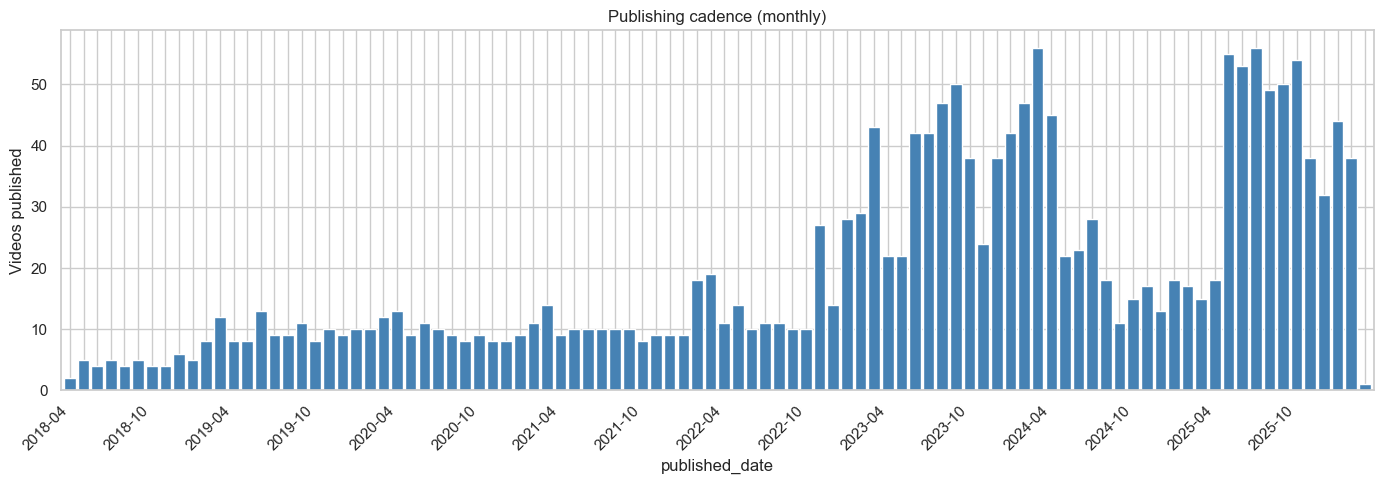

In [6]:
df = df.sort_values("published_date").reset_index(drop=True)

# Videos per month
monthly = df.set_index("published_date").resample("ME").size()

fig, ax = plt.subplots()
monthly.plot(kind="bar", ax=ax, width=0.85, color="steelblue")

# Show only every 6th label to avoid crowding
tick_labels = [d.strftime("%Y-%m") if i % 6 == 0 else "" for i, d in enumerate(monthly.index)]
ax.set_xticklabels(tick_labels, rotation=45, ha="right")
ax.set_ylabel("Videos published")
ax.set_title("Publishing cadence (monthly)")
plt.tight_layout()
plt.show()

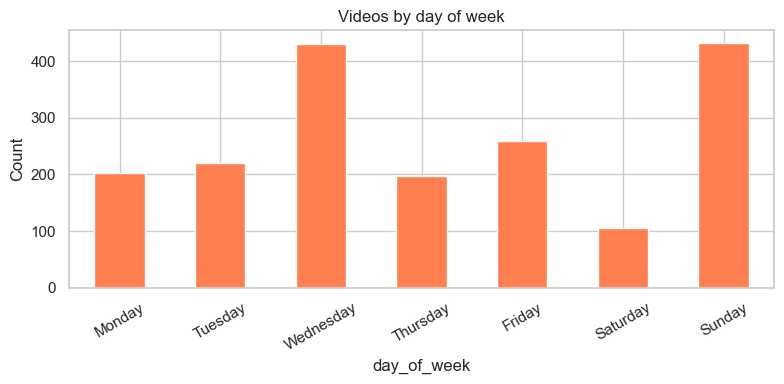

In [7]:
# Day-of-week distribution
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["day_of_week"] = df["published_date"].dt.day_name()
day_counts = df["day_of_week"].value_counts().reindex(day_order)

fig, ax = plt.subplots(figsize=(8, 4))
day_counts.plot(kind="bar", ax=ax, color="coral")
ax.set_ylabel("Count")
ax.set_title("Videos by day of week")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 3 — Engagement metrics

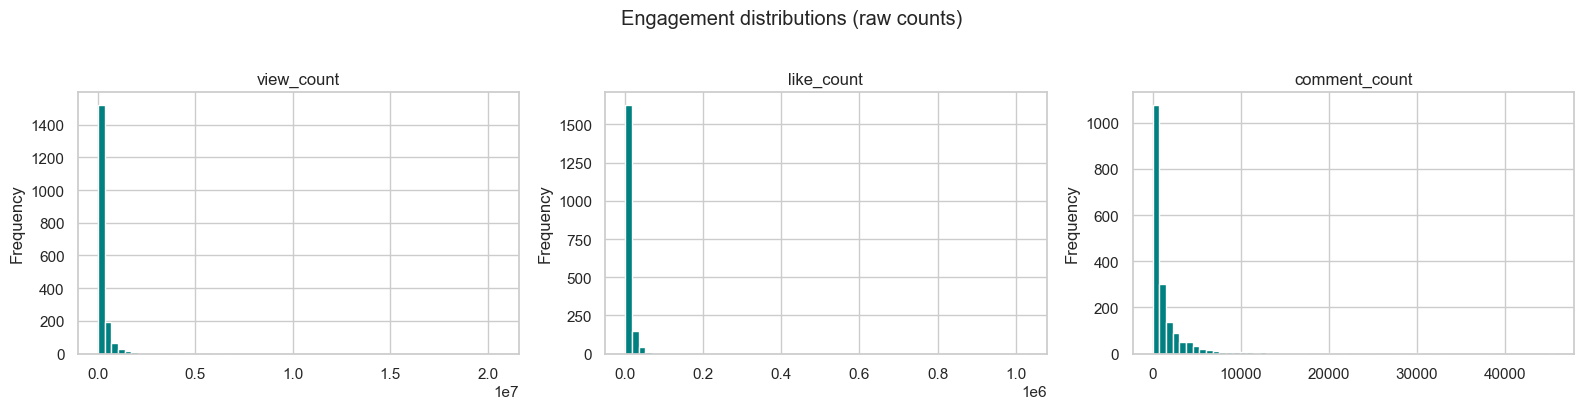

In [8]:
engagement_cols = ["view_count", "like_count", "comment_count"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, engagement_cols):
    df[col].dropna().plot(kind="hist", bins=60, ax=ax, color="teal", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Engagement distributions (raw counts)", y=1.02)
plt.tight_layout()
plt.show()

/var/folders/r9/gmqzlhhd67vdxkgnkq05lj6h0000gn/T/ipykernel_44305/3160686348.py:10: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r9/gmqzlhhd67vdxkgnkq05lj6h0000gn/T/ipykernel_44305/3160686348.py:10: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/stats-notes-python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/stats-notes-python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


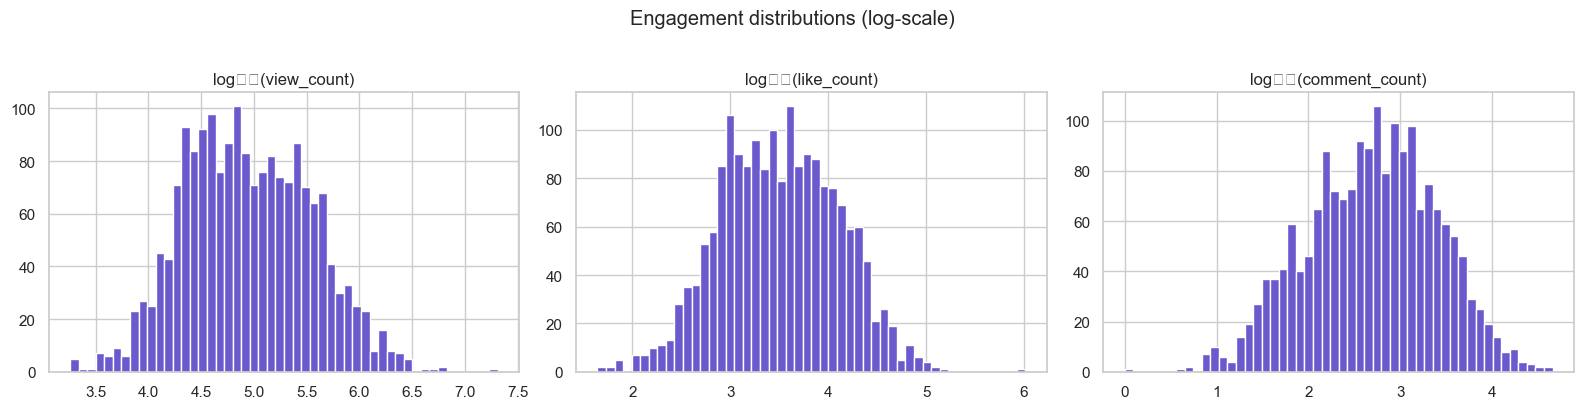

In [9]:
# Log-scale distributions (more readable for skewed data)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, engagement_cols):
    vals = df[col].dropna()
    vals = vals[vals > 0]
    ax.hist(np.log10(vals), bins=50, color="slateblue", edgecolor="white")
    ax.set_title(f"log₁₀({col})")
    ax.set_xlabel("")
plt.suptitle("Engagement distributions (log-scale)", y=1.02)
plt.tight_layout()
plt.show()

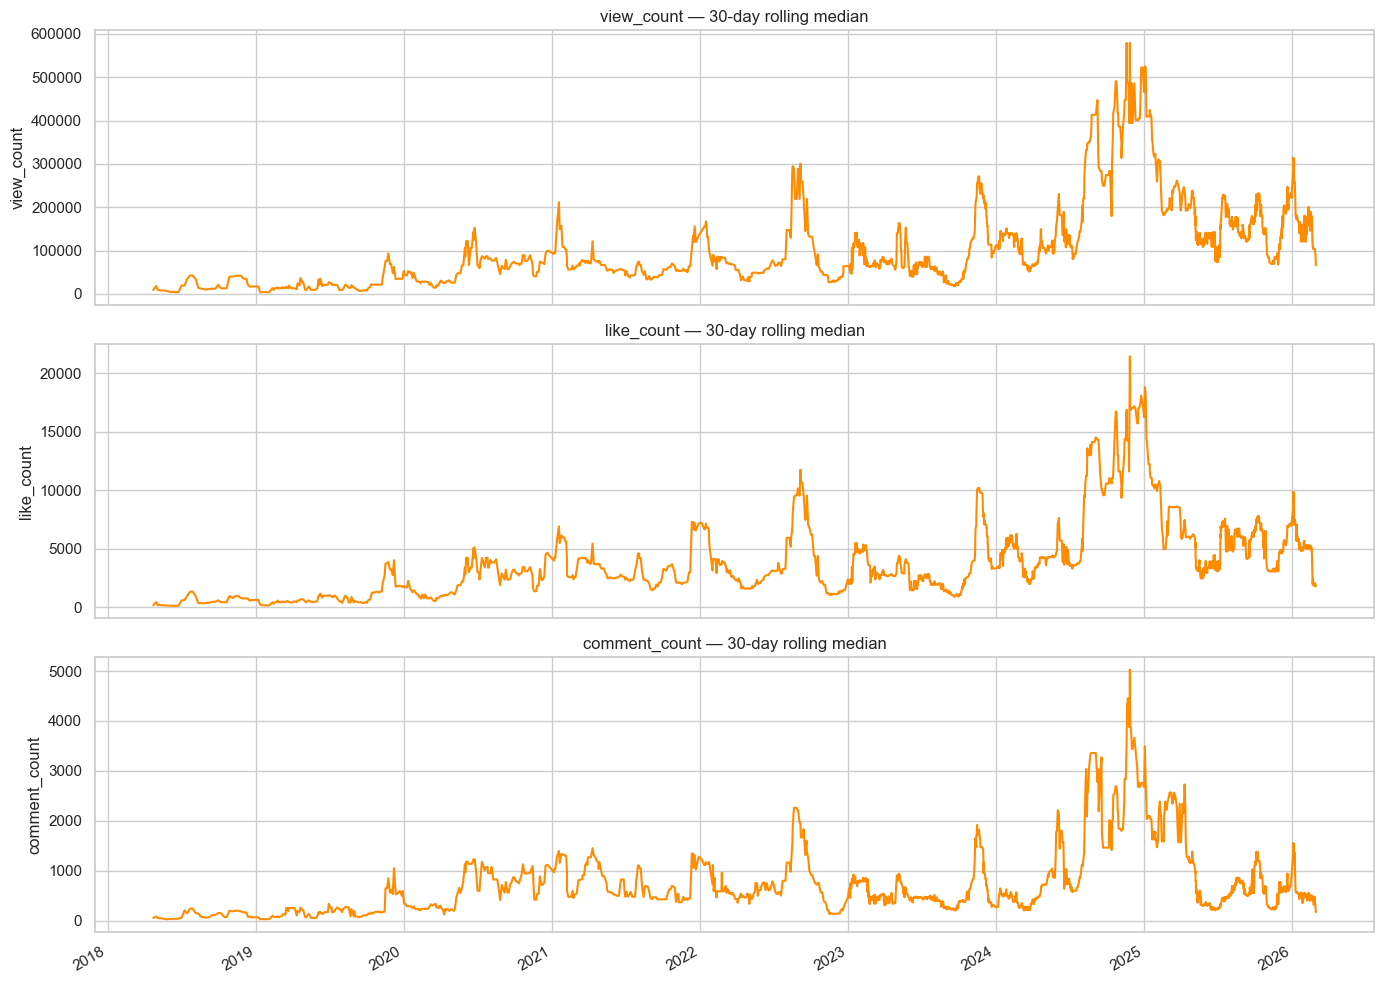

In [10]:
# Engagement over time (rolling 30-day median)
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, col in zip(axes, engagement_cols):
    rolling = df.set_index("published_date")[col].rolling("30D").median()
    rolling.plot(ax=ax, color="darkorange")
    ax.set_ylabel(col)
    ax.set_title(f"{col} — 30-day rolling median")
axes[-1].set_xlabel("")
plt.tight_layout()
plt.show()

In [11]:
# Derived ratios
df["like_per_view"] = df["like_count"] / df["view_count"]
df["comment_per_view"] = df["comment_count"] / df["view_count"]

print("Like / view ratio")
print(df["like_per_view"].describe())
print()
print("Comment / view ratio")
print(df["comment_per_view"].describe())

Like / view ratio
count    1848.000000
mean        0.038590
std         0.014525
min         0.004989
25%         0.028387
50%         0.036329
75%         0.046889
max         0.121758
Name: like_per_view, dtype: float64

Comment / view ratio
count    1848.000000
mean        0.007567
std         0.006136
min         0.000042
25%         0.003392
50%         0.006393
75%         0.009897
max         0.052456
Name: comment_per_view, dtype: float64


## 4 — Video type & category breakdown

In [12]:
print("Video types:")
print(df["type"].value_counts())
print()
print("Category IDs:")
print(df["category_id"].value_counts())

Video types:
type
video         1012
livestream     525
short          312
Name: count, dtype: int64

Category IDs:
category_id
25    1684
22      87
24      44
23      17
27      12
28       3
17       2
Name: count, dtype: int64


## 5 — Tags overview

In [13]:
# Flatten tags
all_tags = df["tags"].dropna().str.split("|").explode().str.strip().str.lower()
tag_counts = all_tags.value_counts()

print(f"Unique tags: {tag_counts.shape[0]:,}")
print(f"Total tag usages: {all_tags.shape[0]:,}")
print()
tag_counts.head(30)

Unique tags: 7,031
Total tag usages: 32,958



tags
triggerpod              1765
konstantin kisin        1765
francis foster          1763
triggernometry          1750
trigonometry            1302
trigger                 1289
kissin                  1270
trig                     965
interview                916
kk                       906
ff                       904
joe rogan                437
jre                      427
rubin report             399
joe rogan experience     358
trump                    119
free speech              103
israel                    86
politics                  85
woke                      74
donald trump              65
trans                     65
immigration               63
america                   63
palestine                 62
russia                    61
uk                        61
comedy                    58
gaza                      57
brexit                    56
Name: count, dtype: int64

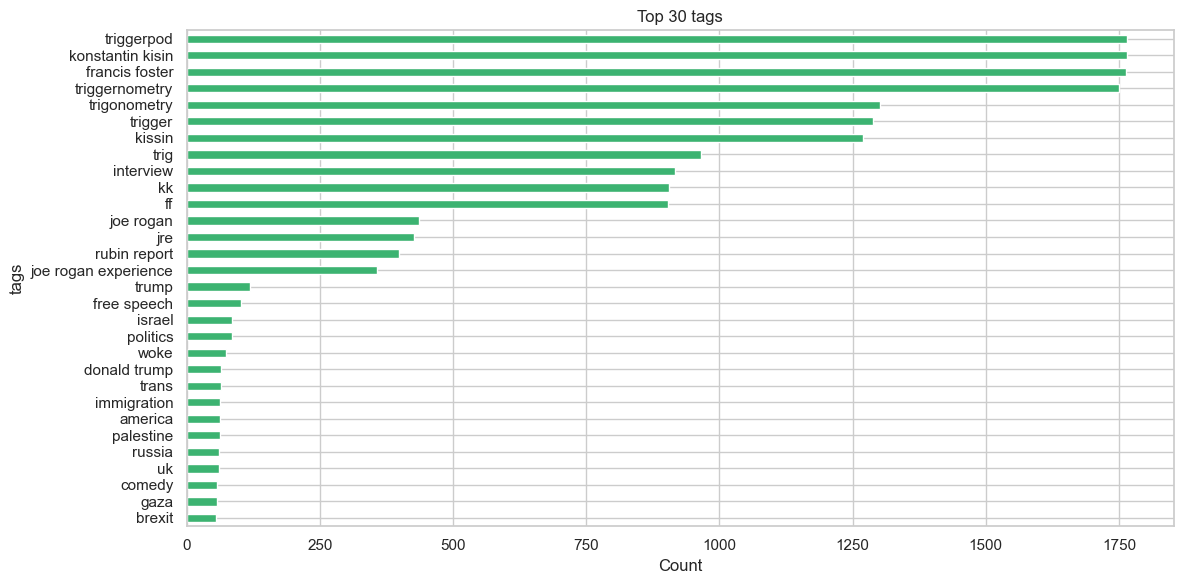

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
tag_counts.head(30).plot(kind="barh", ax=ax, color="mediumseagreen")
ax.invert_yaxis()
ax.set_xlabel("Count")
ax.set_title("Top 30 tags")
plt.tight_layout()
plt.show()

## 6 — Topic categories

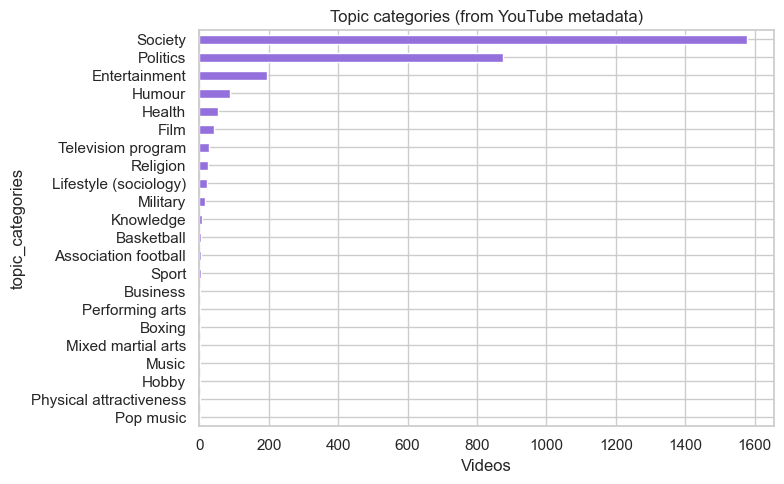

In [15]:
# topic_categories are pipe-separated Wikipedia URLs
all_topics = (
    df["topic_categories"]
    .dropna()
    .str.split("|")
    .explode()
    .str.replace("https://en.wikipedia.org/wiki/", "", regex=False)
    .str.replace("_", " ")
)
topic_counts = all_topics.value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
topic_counts.plot(kind="barh", ax=ax, color="mediumpurple")
ax.invert_yaxis()
ax.set_xlabel("Videos")
ax.set_title("Topic categories (from YouTube metadata)")
plt.tight_layout()
plt.show()

## 7 — Title & description length distributions

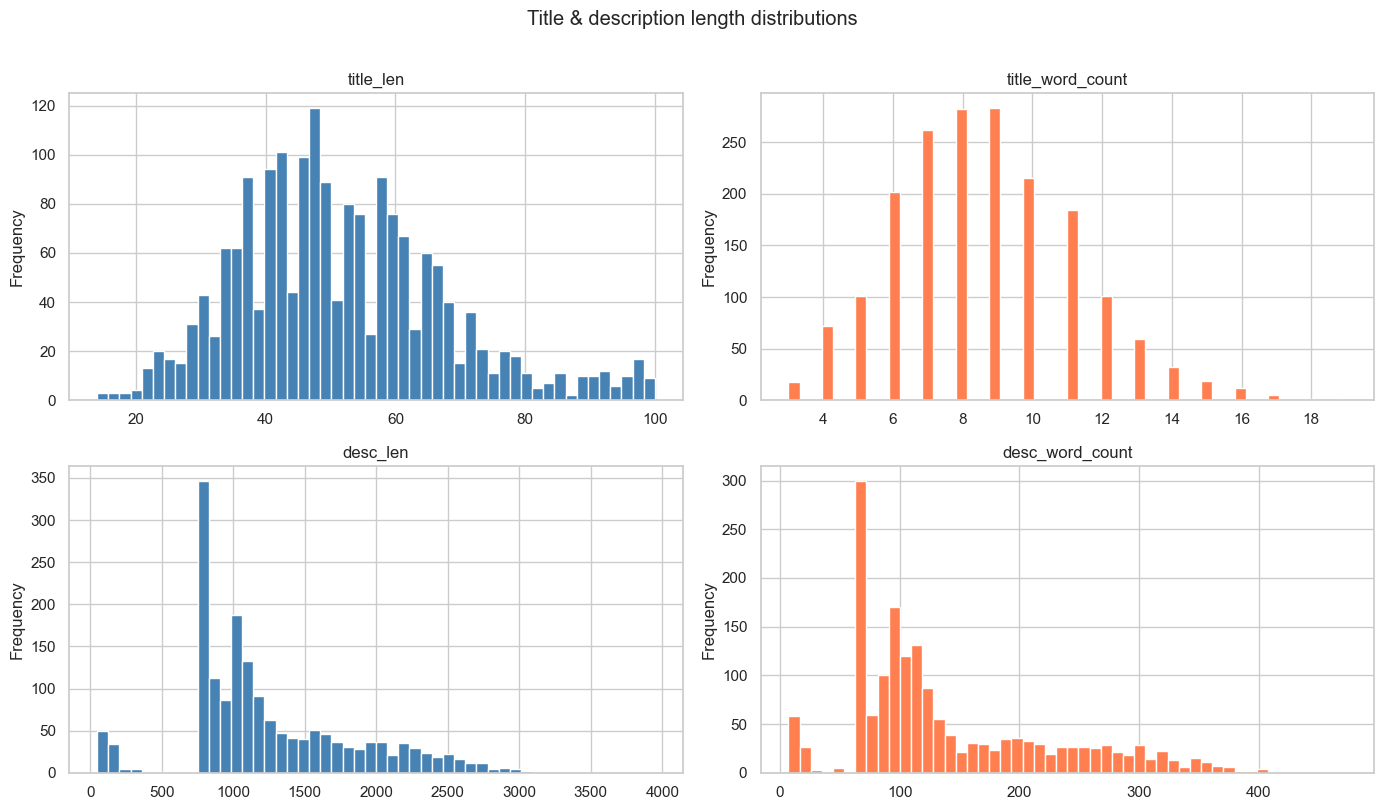

In [16]:
df["title_len"] = df["title"].str.len()
df["title_word_count"] = df["title"].str.split().str.len()
df["desc_len"] = df["description"].str.len()
df["desc_word_count"] = df["description"].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col, colour in zip(
    axes.flat,
    ["title_len", "title_word_count", "desc_len", "desc_word_count"],
    ["steelblue", "coral", "steelblue", "coral"],
):
    df[col].dropna().plot(kind="hist", bins=50, ax=ax, color=colour, edgecolor="white")
    ax.set_title(col)
plt.suptitle("Title & description length distributions", y=1.01)
plt.tight_layout()
plt.show()

## 8 — Top-viewed videos

In [17]:
df.nlargest(20, "view_count")[["published_date", "title", "view_count", "like_count", "comment_count"]]

,published_date,title,view_count,like_count,comment_count
979,2024-01-11,Mind-Blowing Game Invented by Russian Sociolog...,20575018,1028120,29733
1398,2025-05-14,Triggernometry Meets Guilty Feminist,6216319,121694,15745
1414,2025-05-21,Why More Jews Died in the Netherlands Than in ...,5999262,107929,6069
81,2019-06-05,Comedian DESTROYS 3 SJWs with facts and logic ...,4766961,82681,17201
964,2023-12-15,Russia has NEVER had a democracy... #shorts #p...,3894071,122721,6525
632,2023-03-22,Piers Morgan ADMITS he was wrong... (PT1) #shorts,2964942,61956,4126
1006,2024-01-26,Is this the truth about Israel? 🇮🇱🇵🇸 #shorts #...,2873513,66894,19038
1543,2025-08-01,Understanding history means confronting uncomf...,2766635,110872,11272
1403,2025-05-15,Are You Calling Me A Hysterical Woman?,2759432,69851,10702
1609,2025-09-12,Stop Calling Everyone You Disagree With Nazis,2662943,138452,10061


## 9 — Correlation heatmap

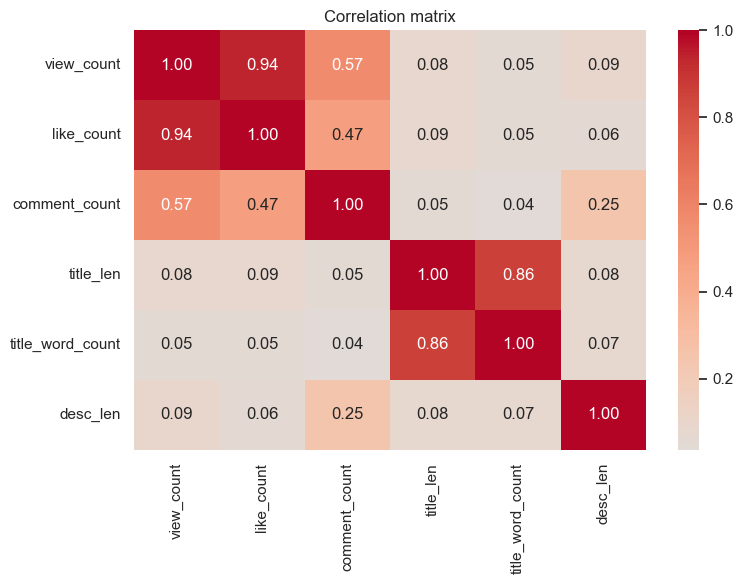

In [18]:
corr_cols = ["view_count", "like_count", "comment_count", "title_len", "title_word_count", "desc_len"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

---

**Summary so far:**  
Quick-look at publishing cadence, engagement distributions and trends, tag/topic breakdowns, and text-length profiles. These baselines inform the deeper word-frequency and NLP analysis in the next notebook.